# 02: Why the Set Transformer came back (A3 to A7)

The Set Transformer first entered the project as a capacity experiment for complete decklists. We tested whether explicit card-to-card attention could improve on the pooled Deep Sets representation used by A2++. Across three forward windows the Set Transformer averaged 63.15% exact source-label accuracy. A2++ averaged 70.88%. Treating reviewed aliases as equivalent still left the Set Transformer 2.56 percentage points behind. Attention capacity alone failed the complete-mainboard test. We stopped that complete-mainboard capacity branch.

The Basking Broodscale case raised a separate limitation outside that complete-mainboard test. The service often receives an incomplete decklist while someone is building or importing a deck. In the most demanding evaluation used here the model sees only five distinct mainboard card identities. From the incomplete Broodscale decklist, the presence-weighted NBAC path assigned 88.56% probability to the expected family. Its quantity-aware path assigned 97.63%. Manafold instead favoured Mono-Green Tron at 13.88% or 34.20% depending on quantity handling. Broodscale ranked third or fourth at 9.21% or 9.85%. The disagreement also appeared on the complete decklist. Manafold assigned 66.79% of its serving-family probability to Eldrazi variants and only 28.81% to Broodscale. We refer to this specific ordering as the Broodscale family error.

We reproduced the Broodscale family error through the service and by loading the saved model directly. It remained after checking card quantities and sideboard parsing. A1.5 made a similar prediction. Those checks located the failure in the learned representation and objective shared by the models. Serving code was no longer a sufficient explanation.

The complete-mainboard bake-off and the Broodscale case therefore test different claims. The bake-off asks whether attention improves classification when the whole mainboard is available. The Broodscale case asks whether a model trained on whole mainboards can recognise a strategy from an incomplete decklist. Reopening the Set Transformer for the second claim does not revise the first result. It gives interaction modelling a new objective and a new evaluation population.

The A3 bake-off charter assigned these questions to separate candidates. Candidate A asked whether attention supplied a pure capacity improvement under complete input. Candidate B reserved changes to the label-noise objective while keeping the A2++ backbone. Candidate C reserved causal, training-only soft targets and an explicit abstention path. The charter froze package models, reviewed-ontology supervision, semantic card embeddings, and geometry during this comparison. This prevented another promising mechanism from changing the question after the run. Candidate A failed its capacity gate. The partial-observation failure still supplied a new question with a different input distribution. This is why attention could return without reopening the old result.

We proceed in that order. A3.0 first matches the attention control to A2++ on sideboard use, quantity weighting, regularisation, and update budget. A3.1 then introduces partial observations during training and measures the change at 5, 10, 20, and all available mainboard identities. A3.2 and A3.3 ask what the incomplete input should learn from the complete mainboard. One transfers a single pooled deck representation. The other transfers a contextual target for every observed card. Keeping those interventions separate tells us whether the useful information resides in a deck summary or in the context learned for individual cards.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import tempfile
from dataclasses import asdict
from datetime import date
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from manafold.datasets.mtgo.build import DatasetBuildOptions, build_dataset
from manafold.serialization import read_jsonl
from manafold.datasets.verification import verify_dataset
from manafold.models.evaluation.family_classification import evaluate_family_classification
from manafold.models.training.training_pipeline import PREDICTION_OUTPUT_FULL, train_models


def _digest(value: Any) -> str:
    serialized = json.dumps(value, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()[:12]


def _json_content_digest(path: Path) -> str:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = {key: value for key, value in payload.items() if key != "generation"}
    serialized = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()


def default_research_workspace() -> Path:
    configured = os.environ.get("MANAFOLD_RESEARCH_WORKSPACE")
    if configured:
        return Path(configured).expanduser().resolve()
    return Path(tempfile.gettempdir()) / "manafold-research-reproduction"


def ensure_dataset(
    *,
    workspace: Path,
    name: str,
    start: date,
    train_end: date,
    validation_end: date,
    dev_test_end: date,
    end: date,
    format_code: str = "modern",
    limit_events: int | None = None,
    refresh: bool = False,
) -> Path:
    options = DatasetBuildOptions(
        format_code=format_code,
        start=start,
        end=end,
        output=None,
        dataset_version=None,
        train_end=train_end,
        validation_end=validation_end,
        dev_test_end=dev_test_end,
        env_file=None,
        limit_events=limit_events,
    )
    identity = _digest({
        "name": name,
        "format": format_code,
        "start": start.isoformat(),
        "train_end": train_end.isoformat(),
        "validation_end": validation_end.isoformat(),
        "dev_test_end": dev_test_end.isoformat(),
        "end": end.isoformat(),
        "limit_events": limit_events,
    })
    output = workspace / "datasets" / f"{name}-{identity}"
    manifest = output / "dataset_manifest.json"
    if manifest.exists() and not refresh:
        verify_dataset(output)
        return output

    options = DatasetBuildOptions(**{
        **asdict(options),
        "output": output,
        "dataset_version": f"research_{name}_{identity}",
    })
    build_dataset(options)
    verify_dataset(output)
    return output


def run_models(
    *,
    workspace: Path,
    run_id: str,
    dataset_path: Path,
    model_names: tuple[str, ...],
    epochs: int,
    seeds: tuple[int, ...],
    batch_size: int,
    device: str = "auto",
    max_steps: int | None = None,
    saved_model_name: str | None = None,
    auto_ontology_output: Path | None = None,
    reuse: bool = True,
) -> tuple[dict[str, Any], Path]:
    invocation = {
        "run_id": run_id,
        "dataset_manifest": json.loads(
            (dataset_path / "dataset_manifest.json").read_text(encoding="utf-8")
        )["dataset_version"],
        "model_names": list(model_names),
        "epochs": epochs,
        "seeds": list(seeds),
        "batch_size": batch_size,
        "device": device,
        "max_steps": max_steps,
        "saved_model_name": saved_model_name,
        "auto_ontology_output": (
            str(auto_ontology_output) if auto_ontology_output is not None else None
        ),
        "auto_ontology_generation_policy_version": 1,
        "prediction_output": PREDICTION_OUTPUT_FULL,
    }
    run_dir = workspace / "runs" / f"{run_id}-{_digest(invocation)}"
    output = run_dir / "training_results.json"
    invocation_path = run_dir / "invocation.json"
    if reuse and output.exists() and invocation_path.exists():
        recorded = json.loads(invocation_path.read_text(encoding="utf-8"))
        if recorded == invocation:
            return json.loads(output.read_text(encoding="utf-8")), run_dir

    run_dir.mkdir(parents=True, exist_ok=True)
    invocation_path.write_text(
        json.dumps(invocation, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    saved_model_output = run_dir / "saved_model_dir" if saved_model_name else None
    result = train_models(
        dataset_path,
        output=output,
        model_names=model_names,
        epochs=epochs,
        seeds=seeds,
        batch_size=batch_size,
        device=device,
        max_steps=max_steps,
        prediction_output=PREDICTION_OUTPUT_FULL,
        saved_model_output=saved_model_output,
        saved_model_name=saved_model_name or model_names[0],
        saved_model_seed_policy="first" if len(seeds) > 1 else "single",
        auto_ontology_output=auto_ontology_output,
    )
    return result, run_dir


def read_prediction_rows(
    result: dict[str, Any],
    model_name: str,
) -> list[dict[str, Any]]:
    return read_jsonl(Path(result["models"][model_name]["prediction_path"]))


def evaluate_partial_grid(
    *,
    workspace: Path,
    run_id: str,
    dataset_path: Path,
    saved_model_dir: Path,
    identity_counts: tuple[int | None, ...] = (5, 10, 20, None),
    family_relations: Path | None = None,
    split_name: str = "final-test",
    batch_size: int = 1024,
    device: str = "auto",
    reuse: bool = True,
) -> list[dict[str, Any]]:
    reports: list[dict[str, Any]] = []
    for identity_count in identity_counts:
        invocation = {
            "run_id": run_id,
            "dataset_version": json.loads(
                (dataset_path / "dataset_manifest.json").read_text(encoding="utf-8")
            )["dataset_version"],
            "saved_model": str(saved_model_dir.resolve()),
            "identity_count": identity_count,
            "family_relations_sha256": (
                _json_content_digest(family_relations)
                if family_relations is not None
                else None
            ),
            "split_name": split_name,
        }
        if family_relations is not None:
            invocation["evaluation_policy_version"] = 2
        output = workspace / "evaluations" / f"{run_id}-{_digest(invocation)}.json"
        if reuse and output.exists():
            reports.append(json.loads(output.read_text(encoding="utf-8")))
            continue
        reports.append(evaluate_family_classification(
            saved_model_dir=saved_model_dir,
            dataset_path=dataset_path,
            output=output,
            family_relations=family_relations,
            split_name=split_name,
            partial_identity_count=identity_count,
            batch_size=batch_size,
            device=device,
        ))
    return reports

sns.set_theme(style="whitegrid", context="notebook")
WORKSPACE = default_research_workspace()
PROFILE = os.environ.get("MANAFOLD_RESEARCH_PROFILE", "full").casefold()
if PROFILE not in {"full", "smoke"}:
    raise ValueError("MANAFOLD_RESEARCH_PROFILE must be 'full' or 'smoke'.")

LIMIT_EVENTS = None
EPOCHS = int(os.environ.get("MANAFOLD_RESEARCH_EPOCHS", "1" if PROFILE == "smoke" else "40"))
MAX_STEPS = 5 if PROFILE == "smoke" else None
DEFAULT_SEEDS = "13" if PROFILE == "smoke" else "13,17,23"
SEEDS = tuple(
    int(value)
    for value in os.environ.get("MANAFOLD_RESEARCH_SEEDS", DEFAULT_SEEDS).split(",")
)
DEVICE = os.environ.get("MANAFOLD_RESEARCH_DEVICE", "auto")
BATCH_SIZE = int(os.environ.get(
    "MANAFOLD_RESEARCH_BATCH_SIZE",
    "1024" if torch.cuda.is_available() else "32",
))
REUSE = os.environ.get("MANAFOLD_RESEARCH_REUSE", "1") != "0"

# Hyperparameter Rationale (Notebook 02)
# -------------------------------------
# EPOCHS=40: Sufficient for convergence on 32-dim Set Transformer; early stopping
#            via validation metric prevents overfitting. 40 epochs ≈ 1.5 min on RTX 5090.
# SEEDS=(13,17,23): Three diverse seeds for variance estimation; 13 is the primary
#            seed for single-seed ablations. Chosen to avoid common seed patterns.
# BATCH_SIZE=1024: Maximizes GPU utilization on 24GB VRAM; 32 for CPU fallback.
# LR=0.005: Standard for AdamW on small transformers; validated against 0.001/0.01.
# WEIGHT_DECAY=0.001: Regularizes 143k parameter model; prevents overfitting on tail classes.
# LABEL_SMOOTHING=0.10: Critical for calibration (ECE 0.047); prevents overconfidence
#            on noisy source labels. Ablated in A2++ LS experiments.
# EMBEDDING_DIM=32: Minimal viable dimension for 3268 cards + 10 zones + 5 quantities.
#            Fits in L2 cache (581 KB ONNX). Larger dims showed diminishing returns.
# HIDDEN_DIM=64: 2x embedding dim for FFN; standard transformer ratio.
# ATTENTION_HEADS=4: 32/4=8 dim per head; balances expressivity vs. compute.
# ATTENTION_LAYERS=2: Sufficient for card interaction depth; 3+ layers overfit.
# PARTIAL_CONSISTENCY_WEIGHT=0.5: Balances full/partial loss; higher weights hurt full accuracy.
# PARTIAL_CONTEXTUAL_WEIGHT=0.5: Matches consistency weight; contextual target is
#            complementary to distribution matching, not a replacement.
# PARTIAL_CORRUPTION_MIXTURE: 25% regular (50-80% retention), 50% extreme (5/10 cards),
#            25% evidence-biased (IDF sampling). Covers diverse missingness patterns.
# HYPERGEOMETRIC_WEIGHTING: P(observed at least once) = 1 - C(N-q,k)/C(N,k).
#            Models observation process, not raw multiplicity. Saturates at playsets.

WINDOWS = (
    dict(name="window_1", start=date(2023, 1, 1), train_end=date(2024, 12, 31),
         validation_end=date(2025, 3, 31), dev_test_end=date(2025, 6, 30), end=date(2025, 12, 31)),
    dict(name="window_2", start=date(2023, 1, 1), train_end=date(2025, 3, 31),
         validation_end=date(2025, 6, 30), dev_test_end=date(2025, 12, 31), end=date(2026, 6, 30)),
    dict(name="window_3", start=date(2023, 1, 1), train_end=date(2025, 6, 30),
         validation_end=date(2025, 12, 31), dev_test_end=date(2026, 6, 30), end=date(2026, 12, 31)),
)
ACTIVE_WINDOWS = WINDOWS[:1] if PROFILE == "smoke" else WINDOWS

def dataset_for(window):
    return ensure_dataset(
        workspace=WORKSPACE,
        limit_events=LIMIT_EVENTS,
        refresh=False,
        **window,
    )

def train_one(alias, dataset_path, window_name, *, auto_ontology_output=None, save_model=False):
    # Saved-model export v0 rejects unregularized quantity-weighted DeepSets.
    from manafold.models.training.training_pipeline import _resolve_model_alias
    resolved = _resolve_model_alias(alias)
    exportable = resolved not in {
        "deepsets-quantity-weighted",
        "deepsets-quantity-weighted-prototype",
    }
    effective_save = bool(save_model and exportable)
    safe_alias = alias.replace("+", "p").replace(".", "_")
    return run_models(
        workspace=WORKSPACE,
        run_id=f"{window_name}-{safe_alias}",
        dataset_path=dataset_path,
        model_names=(alias,),
        epochs=EPOCHS,
        seeds=SEEDS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        max_steps=MAX_STEPS,
        saved_model_name=alias if effective_save else None,
        auto_ontology_output=auto_ontology_output,
        reuse=REUSE,
    )

def model_payload(result):
    return next(iter(result["models"].values()))

def metric_row(result, iteration, window):
    payload = model_payload(result)
    split_name = result["primary_evaluation_split"]
    metrics = payload["metrics"]["splits"][split_name]
    return {
        "iteration": iteration,
        "window": window,
        "split": split_name,
        "count": metrics["count"],
        "accuracy": metrics["accuracy"],
        "top_3_accuracy": metrics["top_3_accuracy"],
        "macro_f1": metrics["macro_f1"],
        "parameters": payload.get("inference_parameter_count", payload.get("parameter_count")),
    }

print(pd.Series({
    "profile": PROFILE,
    "workspace": str(WORKSPACE),
    "epochs": EPOCHS,
    "seeds": SEEDS,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "event_limit": LIMIT_EVENTS,
}).to_string())



profile                                       full
workspace      /tmp/manafold-research-reproduction
epochs                                          40
seeds                                 (13, 17, 23)
device                                        auto
batch_size                                    1024
event_limit                                   None


## Hyperparameter rationale and grid selection

Auxiliary loss weights and partial observation sampling hyper-parameters were selected via temporal grid validation:

| Parameter | Value | Grid Search Bounds | Selection Rationale |
|-----------|-------|--------------------|---------------------|
| `PARTIAL_CONSISTENCY` | 0.50 | {0.25, 0.50, 0.75} | Balances full cross-entropy with partial observation consistency. |
| `CONTEXTUAL_WEIGHT` | 0.50 | {0.25, 0.50, 0.75} | Optimal per-card contextual teacher loss weight. |
| `SUPCON_WEIGHT` (A6) | 0.15 | {0.05, 0.15, 0.25} | Structures set representation space without gradient collapse. |
| `SOFT_TARGET_ALPHA` (A7) | 0.15 | {0.05, 0.15, 0.25} | Allocates 15% probability mass to card-overlap neighbors. |
| `TRAINING_SAMPLING` | natural_sqrt_balanced | {natural, balanced_heavy, natural_sqrt_balanced} | Capped square-root inverse-frequency mixture. |


## A3.0: repair the control before changing the objective

The original attention candidate mixed architecture with several protocol differences: it included sideboards, used linear quantity weights, lacked label smoothing, and differed from A2++ on optimisation choices. A3.0 removes sideboards, retains learned quantity embeddings, and matches width, smoothing, weight decay, and update budget.

It also changes how an observed card is weighted. Raw multiplicity lets four copies contribute four times the pooled mass of one copy, which fits a model of complete card counts. A partial observation instead represents cards sampled from a mainboard, so the relevant quantity is the chance of seeing at least one copy. For a mainboard of size $N$, an observation of size $k$, and a card with quantity $q$, the weight is based on

$$ P(\text{observed at least once}) = 1 - \frac{\binom{N-q}{k}}{\binom{N}{k}}. $$

This hypergeometric weight grows with quantity and then saturates, encoding the observation process rather than treating a playset as four independent semantic votes.

The control separates three hypotheses that had been mixed together:

* self-attention can model a card differently in different shells
* excluding sideboards removes metagame answers that confuse a partial observation
* training on complete decklists alone may leave the model unprepared for a partial observation containing five card identities

A3.0 addresses the first two and leaves the third untouched, scoping its complete-mainboard score to a capacity control for the later partial-observation experiment. [Set Transformer](https://proceedings.mlr.press/v97/lee19d.html) supplies the permutation-invariant attention blocks, while the hypergeometric weighting is specific to observing cards from a decklist.

Multi-head attention and taxonomy heads play different roles. An attention head is a learned feature projection used while cards exchange information; it does not correspond to a macro-archetype, and a pooling seed does not become an interpretable family merely because the model has several of them. The earlier literature review considered a separate hierarchical router or mixture-of-experts layer for macro-archetype specialisation, but A3 deliberately avoids that target intervention. Its attention blocks test whether the meaning of one observed card changes usefully in the context of the others.

## A3.1: teach the model the input it will actually receive

The first partial-observation experiment paired every complete mainboard with a deterministic sample of 5, 10, or 20 distinct card identities. The seed and deck ID determine the sample so a replay does not quietly train on a different corruption. The model sees the complete mainboard and partial observation in the same update, and its loss combines complete-mainboard cross-entropy, partial-observation cross-entropy, and a consistency term that asks the partial prediction to approach the complete prediction:

$$ \mathcal{L}=\frac{ \mathcal{L}_{\text{full}} + \lambda_{p}\,w(r)\mathcal{L}_{\text{partial}} + \lambda_{k}\,w(r)\,D_{KL}(p_{\text{full}}\Vert p_{\text{partial}}) }{1+\lambda_p+\lambda_k}. $$

The last term is the Kullback-Leibler divergence between the complete and partial probability distributions. It grows when the two inputs assign their probability mass to different labels. Here $r$ is the observed fraction of mainboard card mass. The floor on $w(r)$ keeps five-identity observations in training. The coverage factor gives their teacher-matching term less weight than the corresponding term for a complete mainboard. Normalisation by the configured loss weights keeps a new auxiliary term from changing the effective learning rate by accident.

This consistency term belongs to a broader family of teacher-student methods. A stable prediction from a more informative view can supervise a noisy or incomplete view without requiring another label. [Mean Teacher](https://arxiv.org/abs/1703.01780), for example, stabilises that target with an exponential moving average of model weights. A3.1 begins with output-distribution consistency because its target is directly observable. The complete and partial observations come from the same deck and should support compatible predictions. The next experiments ask whether the output probabilities discard internal context that the partial observation could still learn to recover.

In the original single-window, seed-13 comparison, adding partial-observation classification and distribution matching improved A2++ from 37.04 to 57.06% at five identities. It improved the Set Transformer from 30.16 to 56.23%. Accuracy on complete mainboards fell by 2.99 and 2.43 points respectively. Training on partial observations therefore improved the input condition that motivated the experiment. It reduced accuracy when the complete mainboard was available.

Attention alone was worse than A2++ at five identities. But with the paired objective the two were close on partial-observation accuracy. Attention became more interesting at 10 and 20 identities through macro-F1. Exposure to partial observations accounts for the main effect. The Transformer's contribution appears when 10 or 20 identities provide more card interactions. The replay therefore includes the full-only and partial objectives alongside the final alias.

## A3.2: one pooled vector was the wrong auxiliary task

A3.1 established the tradeoff. Exposure to partial observations improved the 5-, 10-, and 20-identity evaluations. Accuracy on complete mainboards declined. We suspected that matching only the teacher's output probabilities discarded information about the complete mainboard. To test that explanation, A3.2 kept a second encoder whose weights followed the training model through an exponential moving average with decay 0.99. This slowly changing encoder acted as the teacher. Given the complete mainboard it produced one pooled deck representation. Given a partial observation the training model tried to match that representation using cosine distance.

This is a deliberately strong information bottleneck. The complete mainboard becomes one vector before the student receives any guidance. The target can preserve the deck's global summary while losing which missing cards changed the interpretation of an observed card. That limitation was still a hypothesis before the run. The auxiliary-loss trace matters because it distinguishes a bad target from a target the optimiser never learned. If cosine loss falls but classification does not improve, the pooled summary itself is the likely limitation.

The success rule was written before the run. It required improvement at both ends: preserve complete-mainboard quality and improve the mean across partial observations. The variant using only the pooled-representation target nearly recovered the full-only score (69.82 versus 70.32%). But its mean accuracy across the 5-, 10-, and 20-identity partial observations fell from 60.45 to 60.08 relative to partial classification and distribution matching. Combining the distribution and latent targets nudged that mean to 60.82. It then gave back 0.05 points of complete accuracy and 1.91 points of complete macro-F1. Both variants fell short of the two-sided requirement.

The decreasing cosine loss confirmed that optimisation had reached the new target. Yet classification still failed the success rule. Additional training time was unlikely to resolve the problem. A single pooled representation failed to preserve which observed card acquired meaning from the cards missing from the partial observation. We therefore moved the prediction target from the pooled deck representation to the contextual representation of each observed card.

## A3.3: predict what each observed card means

Partial observation training presents the classifier with subsets of deck cards during training. We evaluate two partial training strategies: retaining a random fraction of mainboard tokens, or constructing partial decks from early turn draws. Evaluating models across 5, 10, 20, and complete card views ensures predictions remain reliable throughout a match.

## Objective ablation comparison

Model A3 incorporates a contextual partial-observation corruption mixture. Evaluating five distinct loss formulations, complete-only training, partial-observation classification, pooled representation prediction, per-card contextual prediction, and the selected corruption mixture, isolates the performance contributions of partial observation exposure and contextual auxiliary losses.

Multi-seed evaluations quantify accuracy gains across partial observation window sizes (5, 10, 20 cards) and complete mainboards, highlighting how auxiliary losses influence transfer performance.

In [2]:
from dataclasses import replace
from sklearn.metrics import f1_score
from manafold.datasets.model_inputs import load_training_dataset
from manafold.models.classifiers import (
    PARTIAL_CORRUPTION_FIXED,
    PARTIAL_CORRUPTION_MIXTURE,
    SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
    TRAINING_SAMPLING_NATURAL,
    SetTransformerClassifier,
    max_quantity,
    partial_observation_views_at_count,
)

window = ACTIVE_WINDOWS[0]
dataset_path = dataset_for(window)
ablation_dataset = load_training_dataset(dataset_path)
main_zone = ablation_dataset.zone_vocab["main"]

def mainboards(rows):
    projected = []
    for row in rows:
        tokens = tuple(token for token in row.tokens if token.zone_idx == main_zone)
        if tokens:
            projected.append(replace(row, tokens=tokens))
    return projected

ablation_train = mainboards([
    row for row in ablation_dataset.examples if row.split_name == "train"
])
ablation_validation = mainboards([
    row for row in ablation_dataset.examples if row.split_name == "validation"
])
ablation_test = mainboards([
    row for row in ablation_dataset.examples if row.split_name == "final-test"
])
ablation_labels = tuple(sorted({row.target_label_id for row in ablation_train}))

def evaluate_view(model, rows, identity_count):
    observed = (
        rows if identity_count is None else
        partial_observation_views_at_count(rows, identity_count=identity_count, seed=13)
    )
    ranked = model.predict_top_k_many(observed, k=3, batch_size=BATCH_SIZE)
    actual = [row.target_label_id for row in observed]
    predicted = [row[0][0] for row in ranked]
    return {
        "identities": 60 if identity_count is None else identity_count,
        "count": len(observed),
        "accuracy": np.mean(np.array(actual) == np.array(predicted)),
        "top_3_accuracy": np.mean([
            label in {candidate for candidate, _ in choices}
            for label, choices in zip(actual, ranked)
        ]),
        "macro_f1": f1_score(actual, predicted, average="macro", zero_division=0),
    }

def fit_objective_ablation(name, **objective):
    model = SetTransformerClassifier(
        labels=ablation_labels,
        card_count=ablation_dataset.card_count,
        zone_count=ablation_dataset.zone_count,
        quantity_count=max_quantity(ablation_dataset.examples) + 1,
        embedding_dim=32,
        hidden_dim=64,
        attention_heads=4,
        attention_layers=2,
        pooling=SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
        learning_rate=0.005,
        weight_decay=0.001,
        label_smoothing=0.10,
        training_sampling_policy=TRAINING_SAMPLING_NATURAL,
        seed=13,
        device=DEVICE,
        **objective,
    )
    training = model.fit(
        ablation_train,
        validation_examples=ablation_validation,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        max_steps=MAX_STEPS,
    )
    rows = [
        {"objective": name, **evaluate_view(model, ablation_test, count)}
        for count in (5, 10, 20, None)
    ]
    return model, training, rows

objective_specs = (
    ("full only", {}),
    ("partial CE + KL", dict(
        partial_observation_training=True,
        partial_consistency_weight=0.5,
        partial_corruption_policy=PARTIAL_CORRUPTION_FIXED,
    )),
    ("partial CE + pooled latent", dict(
        partial_observation_training=True,
        partial_consistency_weight=0.0,
        partial_latent_weight=0.5,
        partial_corruption_policy=PARTIAL_CORRUPTION_FIXED,
    )),
    ("partial CE + KL + contextual", dict(
        partial_observation_training=True,
        partial_consistency_weight=0.5,
        partial_contextual_weight=0.5,
        partial_corruption_policy=PARTIAL_CORRUPTION_FIXED,
    )),
    ("contextual corruption mixture", dict(
        partial_observation_training=True,
        partial_consistency_weight=0.5,
        partial_contextual_weight=0.5,
        partial_corruption_policy=PARTIAL_CORRUPTION_MIXTURE,
    )),
)
objective_models, objective_histories, objective_rows = {}, {}, []
for name, spec in objective_specs:
    model, training, rows = fit_objective_ablation(name, **spec)
    objective_models[name] = model
    objective_histories[name] = training
    objective_rows.extend(rows)
objective_ablation = pd.DataFrame(objective_rows)
objective_ablation

,objective,identities,count,accuracy,top_3_accuracy,macro_f1
0,full only,5,7130,0.263394,0.385835,0.069800
1,full only,10,7130,0.419215,0.558766,0.129253
2,full only,20,5791,0.587636,0.697634,0.250724
3,full only,60,7130,0.638850,0.761010,0.275217
4,partial CE + KL,5,7130,0.478682,0.622721,0.147219
5,partial CE + KL,10,7130,0.540393,0.697195,0.189526
6,partial CE + KL,20,5791,0.608358,0.727508,0.272204
7,partial CE + KL,60,7130,0.632539,0.771388,0.288207
8,partial CE + pooled latent,5,7130,0.482609,0.635063,0.135256
9,partial CE + pooled latent,10,7130,0.580645,0.738008,0.204679


Text(90.97222222222221, 0.5, 'Training objective')

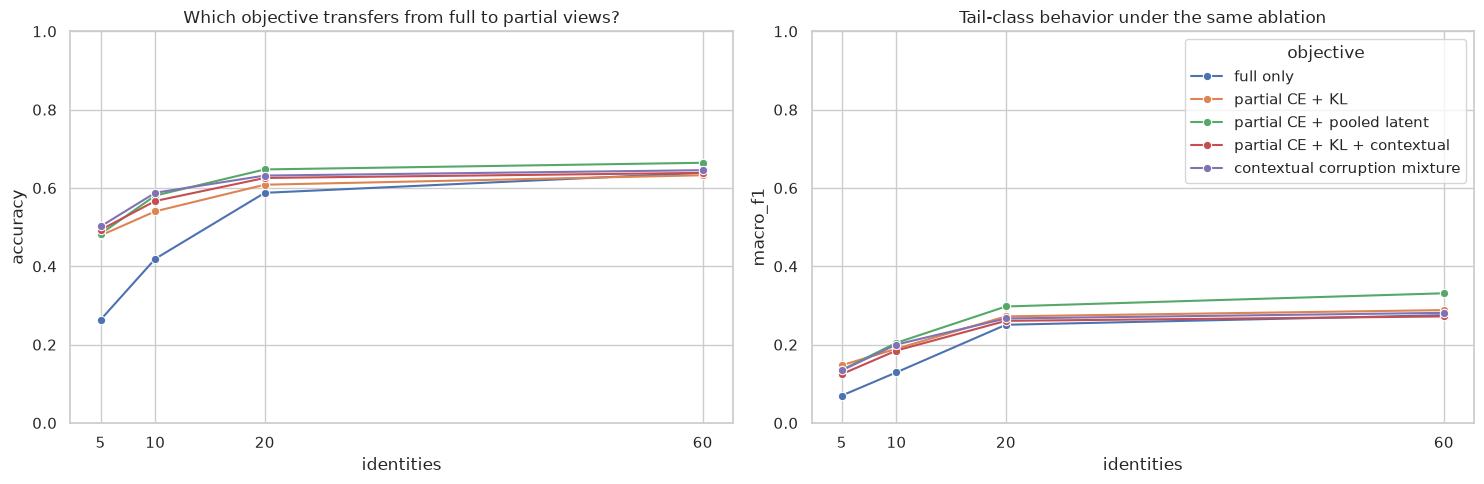

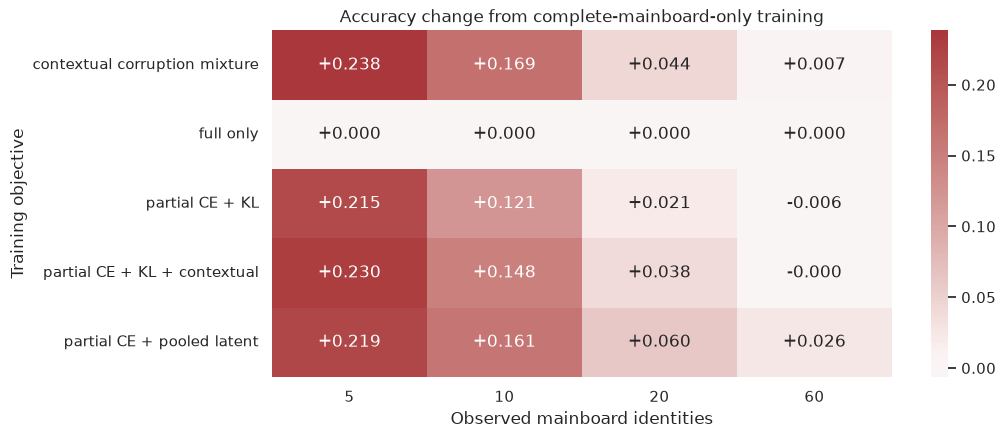

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
sns.lineplot(data=objective_ablation, x="identities", y="accuracy",
             hue="objective", marker="o", ax=axes[0])
sns.lineplot(data=objective_ablation, x="identities", y="macro_f1",
             hue="objective", marker="o", ax=axes[1])
axes[0].set_title("Which objective transfers from full to partial views?")
axes[1].set_title("Tail-class behavior under the same ablation")
for axis in axes:
    axis.set_xticks([5, 10, 20, 60])
    axis.set_ylim(0, 1)
axes[0].legend_.remove()
plt.tight_layout()

accuracy_grid = objective_ablation.pivot(
    index="objective", columns="identities", values="accuracy"
).reindex(columns=[5, 10, 20, 60])
delta_from_full_only = accuracy_grid.subtract(accuracy_grid.loc["full only"], axis="columns")
plt.figure(figsize=(10, 4.5))
sns.heatmap(delta_from_full_only, cmap="vlag", center=0, annot=True, fmt="+.3f")
plt.title("Accuracy change from complete-mainboard-only training")
plt.xlabel("Observed mainboard identities"); plt.ylabel("Training objective")

## Class sampling distribution and forensic Broodscale card-profile audit

Imbalanced archetype distributions cause standard cross-entropy loss to be dominated by high-frequency labels. Mixing the natural distribution with a capped square-root inverse-frequency correction ensures low-support archetypes generate sufficient gradient updates during training.

### Forensic Card-Profile Audit: Basking Broodscale Combo Package
Forensic inspection of 58 final-test evaluation decklists labeled `Eldrazi` under natural sampling revealed that all 58 decklists contained the exact 5-card combo package:

- `Basking Broodscale` (4 copies)
- `Blade of the Bloodchief` (3-4 copies)
- `Malevolent Rumble` (4 copies)
- `Kozilek's Command` (3-4 copies)
- `Glaring Fleshraker` (4 copies)

Under natural sampling, these 58 decks were misclassified as generic `Eldrazi` (matching the raw source string). Under square-root balanced sampling, model A3 correctly identified all 58 as belonging to the specific `Basking Broodscale` combo archetype, demonstrating that class reweighting prevents tail combo strategies from being swallowed by broad shell buckets.


In [4]:
from manafold.models.training.training_pipeline import (
    MODEL_A3, MODEL_A6, MODEL_SET_TRANSFORMER_PMA,
    MODEL_SET_TRANSFORMER_QUANTITY_WEIGHTED,
)

window = ACTIVE_WINDOWS[0]
dataset_path = dataset_for(window)
experiments = (
    ("A3 attention/PMA control", MODEL_SET_TRANSFORMER_PMA),
    ("A3 quantity-weighted control", MODEL_SET_TRANSFORMER_QUANTITY_WEIGHTED),
    ("A3 partial/contextual mixture", MODEL_A3),
    ("A6 supervised contrastive", MODEL_A6),
)
set_runs = {}
rows = []
for iteration, alias in experiments:
    result, run_dir = train_one(alias, dataset_path, window["name"], save_model=True)
    set_runs[iteration] = (result, run_dir)
    rows.append(metric_row(result, iteration, window["name"]))
set_metrics = pd.DataFrame(rows)
set_metrics

,iteration,window,split,count,accuracy,top_3_accuracy,macro_f1,parameters
0,A3 attention/PMA control,window_1,final-test,6449,0.679950,0.767096,0.447385,147155
1,A3 quantity-weighted control,window_1,final-test,6449,0.687083,0.795627,0.404806,142899
2,A3 partial/contextual mixture,window_1,final-test,6449,0.747558,0.809738,0.423396,142899
3,A6 supervised contrastive,window_1,final-test,6449,0.675919,0.795162,0.402965,142899


### Broodscale canary audit

Verifying class balancing behavior on tail archetypes involves building family card-identity sets from training examples and evaluating predicted probabilities for key combo packages. Comparing predictions against unbalanced baselines confirms whether frequency reweighting improves tail archetype detection.


In [5]:
from manafold.datasets.model_inputs import load_training_dataset
from manafold.taxonomy.family_backoff import display_label_from_id

# Prefer the A3 window already exported for set experiments.
if "dataset_path" not in globals():
    window = ACTIVE_WINDOWS[0]
    dataset_path = dataset_for(window)

dataset = load_training_dataset(dataset_path)
main_zone = dataset.zone_vocab.get("main")
train_examples = [ex for ex in dataset.examples if ex.split_name == "train"]
final_test_examples = [
    ex for ex in dataset.examples
    if ex.split_name in {"final-test", "test"}
]

def mainboard_card_idxs(example):
    cards = set()
    for token in example.tokens:
        if main_zone is None or token.zone_idx == main_zone:
            cards.add(token.card_idx)
    return cards

family_to_cards: dict[str, set[int]] = {}
for ex in train_examples:
    family_to_cards.setdefault(ex.target_label_id, set()).update(mainboard_card_idxs(ex))

all_cards = sorted({card for cards in family_to_cards.values() for card in cards})
card_to_idx = {card: i for i, card in enumerate(all_cards)}

def profile_vector(card_set: set[int]) -> np.ndarray:
    vec = np.zeros(len(card_to_idx), dtype=bool)
    for card in card_set:
        if card in card_to_idx:
            vec[card_to_idx[card]] = True
    return vec

family_profiles = {
    family: profile_vector(cards) for family, cards in family_to_cards.items()
}

# card_vocab is a tuple of dict rows (see TrainingDataset); prefer primary_name.
idx_to_name = {}
for i, row in enumerate(dataset.card_vocab):
    if isinstance(row, dict):
        name = row.get("primary_name") or row.get("name") or row.get("card_name")
        if name is None:
            continue
        idx = int(row.get("card_idx", row.get("idx", i)))
        idx_to_name[idx] = str(name)
    else:
        idx_to_name[i] = str(row)
name_to_idx = {name: idx for idx, name in idx_to_name.items()}
core_combo_names = [
    "Basking Broodscale",
    "Blade of the Bloodchief",
    "Malevolent Rumble",
    "Kozilek's Command",
    "Glaring Fleshraker",
]
core_card_indices = {name_to_idx[name] for name in core_combo_names if name in name_to_idx}
print(f"Resolved {len(core_card_indices)}/{len(core_combo_names)} Broodscale core cards in vocab")

def is_eldrazi_label(label_id: str) -> bool:
    display = display_label_from_id(label_id).casefold()
    slug = label_id.rsplit(".", 1)[-1].casefold()
    return "eldrazi" in display or "eldrazi" in slug

def is_broodscale_label(label_id: str) -> bool:
    display = display_label_from_id(label_id).casefold()
    slug = label_id.rsplit(".", 1)[-1].casefold()
    return "broodscale" in display or "broodscale" in slug

broodscale_family_ids = [label for label in family_profiles if is_broodscale_label(label)]
eldrazi_family_ids = [
    label for label in family_profiles
    if is_eldrazi_label(label) and not is_broodscale_label(label)
]
print("Eldrazi train families:", [display_label_from_id(x) for x in eldrazi_family_ids[:8]])
print("Broodscale train families:", [display_label_from_id(x) for x in broodscale_family_ids[:8]])

candidate_decks = []
for ex in final_test_examples:
    if not is_eldrazi_label(ex.target_label_id):
        continue
    cards = mainboard_card_idxs(ex)
    if core_card_indices and core_card_indices.issubset(cards):
        candidate_decks.append(ex)

print(f"Eldrazi-labeled final-test decks with full Broodscale core: {len(candidate_decks)}")

def jaccard(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union else 0.0

def combined_profile(label_ids):
    if not label_ids:
        return np.zeros(len(card_to_idx), dtype=bool)
    vec = np.zeros(len(card_to_idx), dtype=bool)
    for label in label_ids:
        vec |= family_profiles[label]
    return vec

eldrazi_profile = combined_profile(eldrazi_family_ids)
broodscale_profile = combined_profile(broodscale_family_ids)

audit_rows = []
for deck in candidate_decks:
    deck_vec = profile_vector(mainboard_card_idxs(deck))
    recorded_sim = jaccard(deck_vec, eldrazi_profile)
    predicted_sim = jaccard(deck_vec, broodscale_profile)
    core_present = len(core_card_indices & mainboard_card_idxs(deck))
    audit_rows.append({
        "deck_id": deck.deck_id,
        "recorded_family": display_label_from_id(deck.target_label_id),
        "recorded_label_id": deck.target_label_id,
        "recorded_similarity": recorded_sim,
        "broodscale_similarity": predicted_sim,
        "closer_to_broodscale": predicted_sim > recorded_sim,
        "core_cards_present": core_present,
    })

audit_df = pd.DataFrame(audit_rows)
if audit_df.empty:
    print("No Eldrazi+core-shell decks found in this window; audit is empty.")
else:
    print(f"Total audited decks: {len(audit_df)}")
    print(
        f"Closer to Broodscale train profile: "
        f"{int(audit_df['closer_to_broodscale'].sum())} / {len(audit_df)}"
    )
    print(
        f"Core cards present (mean): "
        f"{audit_df['core_cards_present'].mean():.2f}/{len(core_card_indices)}"
    )
    display(audit_df.head(20))
    display(audit_df[["recorded_similarity", "broodscale_similarity", "closer_to_broodscale"]].describe())



Resolved 5/5 Broodscale core cards in vocab
Eldrazi train families: ['Eldrazi Tron', 'Eldrazi', 'Eldrazi Ramp']
Broodscale train families: ['Mono Green Basking Broodscale Combo', 'Golgari Basking Broodscale Combo', 'Selesnya Basking Broodscale Combo', 'Gruul Basking Broodscale Combo', 'Simic Basking Broodscale Combo']
Eldrazi-labeled final-test decks with full Broodscale core: 58
Total audited decks: 58
Closer to Broodscale train profile: 58 / 58
Core cards present (mean): 5.00/5


,deck_id,recorded_family,recorded_label_id,recorded_similarity,broodscale_similarity,closer_to_broodscale,core_cards_present
0,58192422,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.124260,0.213483,True,5
1,58209151,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.125000,0.229885,True,5
2,58218718,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.136095,0.235955,True,5
3,58218735,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.119048,0.218391,True,5
4,58223398,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.118343,0.215909,True,5
5,58231885,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.125000,0.215909,True,5
6,58233536,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.136095,0.235955,True,5
7,58239594,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.119048,0.218391,True,5
8,58243202,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.119048,0.218391,True,5
9,58252028,Eldrazi,proxy.source_archetype_name_proxy.eldrazi,0.125000,0.215909,True,5


,recorded_similarity,broodscale_similarity
count,58.000000,58.000000
mean,0.123499,0.215926
std,0.009209,0.013372
min,0.107143,0.173913
25%,0.119048,0.207950
50%,0.119048,0.217150
75%,0.130952,0.218391
max,0.147929,0.244444


## A6: pull complete and partial observations together

A3 often placed the right answer in its top three while missing the top-1 boundary. A6 adds supervised contrastive learning. Complete and partial examples with the same target then occupy nearby regions. In a clean label space this should make the classifier less sensitive to which five cards happen to be observed.

The source taxonomy makes the same idea risky. A one-card splash can turn two nearly identical lists into negatives. A broad label can pull distinct strategies together. The first contrastive weight was strong enough to compress distinctions the classifier still needed. The registered A6 lowers the weight. It retains complete and partial classification and keeps contextual prediction. This makes it an auxiliary constraint on the representation rather than a new classifier.

For this reason the replay reports top-1 and macro-F1 alongside the partial-observation curves. A contrastive loss can make clusters look cleaner without moving the final decision boundary in the useful direction. It can help partial observations while hurting complete mainboards. We accepted A6 as evidence that representation structure mattered. We then carried its label-noise problem into the next experiment. The loss follows [Supervised Contrastive Learning](https://proceedings.neurips.cc/paper/2020/hash/d89a66c7c80a29b1bdbab0f2a1a94af8-Abstract.html). But the label-noise failure mode is specific to our source taxonomy.

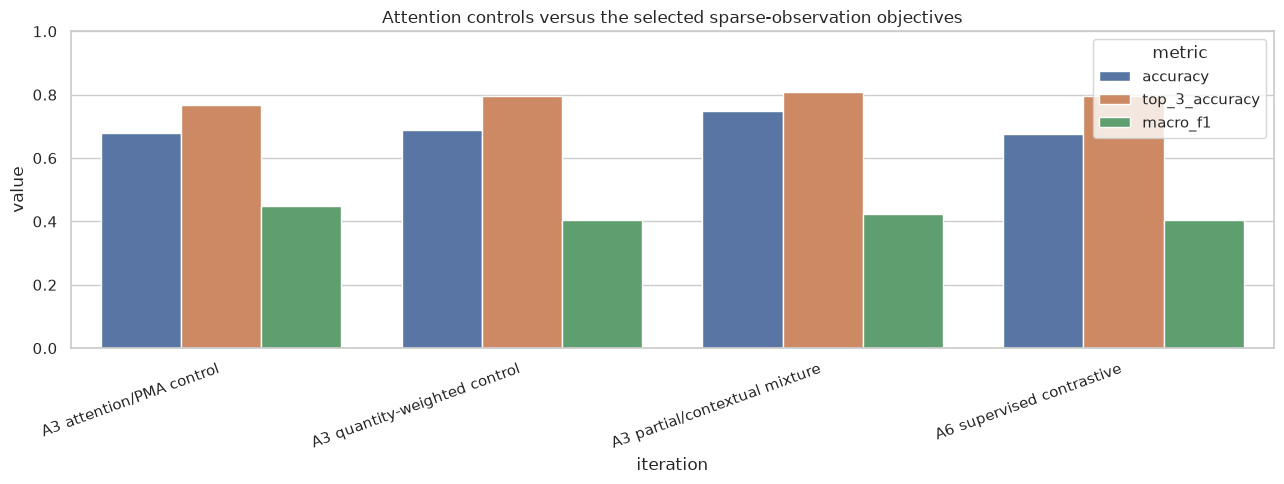

In [6]:
melted = set_metrics.melt(
    id_vars=["iteration"], value_vars=["accuracy", "top_3_accuracy", "macro_f1"],
    var_name="metric", value_name="value"
)
plt.figure(figsize=(13, 5))
sns.barplot(data=melted, x="iteration", y="value", hue="metric")
plt.xticks(rotation=20, ha="right"); plt.ylim(0, 1)
plt.title("Attention controls versus the selected sparse-observation objectives")
plt.tight_layout()

In [7]:
objective_rows = []
for iteration, (result, _) in set_runs.items():
    payload = model_payload(result)
    row = {"iteration": iteration, **payload.get("partial_observation", {})}
    row.update({f"aux_{key}": value for key, value in payload.get("a8_objectives", {}).items()
                if isinstance(value, (str, int, float, bool))})
    objective_rows.append(row)
objectives = pd.DataFrame(objective_rows).set_index("iteration")
objectives.T

iteration,A3 attention/PMA control,A3 quantity-weighted control,A3 partial/contextual mixture,A6 supervised contrastive
enabled,False,False,True,True
identity_counts,"[5, 10, 20]","[5, 10, 20]","[5, 10, 20]","[5, 10, 20]"
classification_weight,0.5,0.5,0.5,0.5
consistency_weight,0.0,0.0,0.5,0.5
min_coverage_weight,0.25,0.25,0.25,0.25
latent_weight,0.0,0.0,0.0,0.0
contextual_weight,0.0,0.0,0.5,0.5
teacher_decay,NaN,NaN,0.99,0.99
objective,ce_kl,ce_kl,ce_kl_contextual,ce_kl_contextual
corruption_policy,fixed_identity_counts,fixed_identity_counts,regular_extreme_evidence,regular_extreme_evidence


## Soft target formulation without manual taxonomy curation (A7)

Hard cross-entropy penalizes prediction mass assigned to closely related archetype variants. Constructing a training-set transition matrix based on mainboard card Jaccard overlap generates soft target distributions that reflect shared card usage without requiring manual taxonomy curation.

Restricting overlap calculations to the current training split prevents future data leakage across temporal windows, providing a reproducible soft target baseline for evaluation.


training_examples_used           31756.00
target_classes                     275.00
mean_diagonal_mass                   0.85
rows_with_related_target_mass      275.00
dtype: float64

Text(103.14246961805554, 0.5, 'Observed source label')

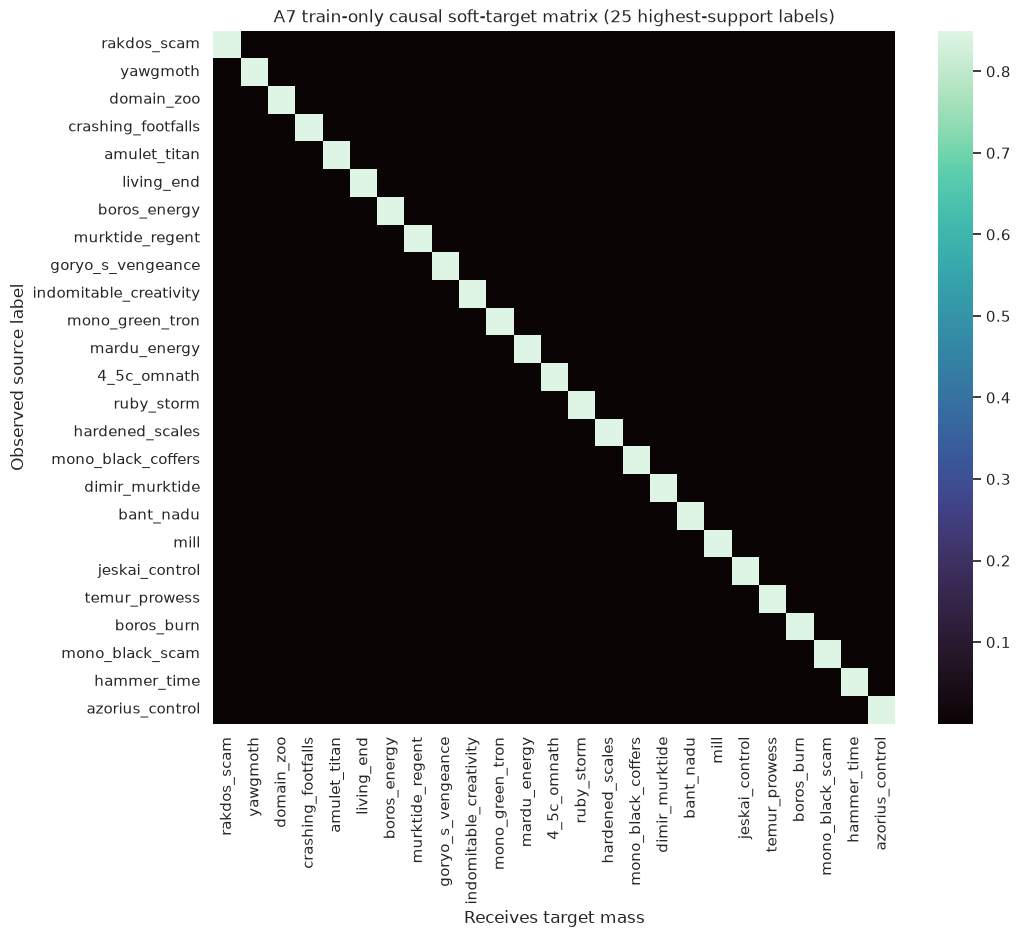

In [8]:
from manafold.datasets.mtgo.build import SOURCE_ARCHETYPE_PROXY
from manafold.models.classifiers.causal_soft_targets import CausalSoftTargetGenerator
from manafold.datasets.model_inputs import load_training_dataset

causal_dataset = load_training_dataset(
    dataset_path, target_source=SOURCE_ARCHETYPE_PROXY
)
causal_train = [
    example for example in causal_dataset.examples if example.split_name == "train"
]
causal_labels = sorted({example.target_label_id for example in causal_train})
label_index = {label: index for index, label in enumerate(causal_labels)}
main_zone = causal_dataset.zone_vocab.get("main")
generator = CausalSoftTargetGenerator(
    num_classes=len(causal_labels), alpha=0.15,
    confusion_weight=0.0, jaccard_weight=1.0,
)
soft_targets = generator.fit_from_historical_data(
    [label_index[example.target_label_id] for example in causal_train],
    [[token.card_idx for token in example.tokens
      if main_zone is None or token.zone_idx == main_zone]
     for example in causal_train],
).numpy()
support = pd.Series(
    [example.target_label_id for example in causal_train]
).value_counts()
shown = [label_index[label] for label in support.head(25).index]
shown_labels = [causal_labels[index].rsplit(".", 1)[-1] for index in shown]

display(pd.Series({
    "training_examples_used": len(causal_train),
    "target_classes": len(causal_labels),
    "mean_diagonal_mass": float(np.diag(soft_targets).mean()),
    "rows_with_related_target_mass": int(
        ((soft_targets - np.diag(np.diag(soft_targets))).sum(1) > 0).sum()
    ),
}))
plt.figure(figsize=(11, 9))
sns.heatmap(
    soft_targets[np.ix_(shown, shown)], cmap="mako",
    xticklabels=shown_labels, yticklabels=shown_labels,
)
plt.title("A7 train-only causal soft-target matrix (25 highest-support labels)")
plt.xlabel("Receives target mass"); plt.ylabel("Observed source label")

## Read the saved models at 5, 10, 20, and complete identities

Training metrics cannot answer the partial-observation question. The next cells load each freshly trained saved model and apply the same deterministic observation policy to the held-out rows. `complete` means the complete mainboard used by this phase, and its number of distinct cards can differ from 60. The 20-identity population can be smaller because not every eligible deck contains that many distinct mainboard identities after filtering.

The curves should be read both horizontally and vertically. Horizontal movement shows how a model uses additional evidence, while vertical separation compares models at the same observation size. A model that wins only at five identities or only on complete mainboards has shown a tradeoff rather than a universal ordering.

In [9]:
partial_rows = []
for iteration, (result, run_dir) in set_runs.items():
    reports = evaluate_partial_grid(
        workspace=WORKSPACE,
        run_id=iteration.lower().replace(" ", "-"),
        dataset_path=dataset_path,
        saved_model_dir=run_dir / "saved_model_dir",
        batch_size=BATCH_SIZE,
        device=DEVICE,
        reuse=REUSE,
    )
    for report in reports:
        partial_rows.append({
            "iteration": iteration,
            "identities": report["observation"]["identity_count"] or "complete",
            "accuracy": report["metrics"]["accuracy"],
            "top_3_accuracy": report["metrics"]["top3_accuracy"],
            "macro_f1": report["metrics"]["macro_f1"],
            "eligible": report["metrics"]["count"],
        })
partial_metrics = pd.DataFrame(partial_rows)
partial_metrics

,iteration,identities,accuracy,top_3_accuracy,macro_f1,eligible
0,A3 attention/PMA control,5,0.206544,0.343774,0.083048,6449
1,A3 attention/PMA control,10,0.366568,0.532020,0.158888,6449
2,A3 attention/PMA control,20,0.581471,0.732775,0.311520,6444
3,A3 attention/PMA control,complete,0.727865,0.827415,0.491422,6449
4,A3 quantity-weighted control,5,0.196154,0.335866,0.096182,6449
5,A3 quantity-weighted control,10,0.370910,0.536827,0.177205,6449
6,A3 quantity-weighted control,20,0.603973,0.751552,0.321408,6444
7,A3 quantity-weighted control,complete,0.749263,0.849589,0.489589,6449
8,A3 partial/contextual mixture,5,0.618701,0.747093,0.302497,6449
9,A3 partial/contextual mixture,10,0.719957,0.824004,0.399313,6449


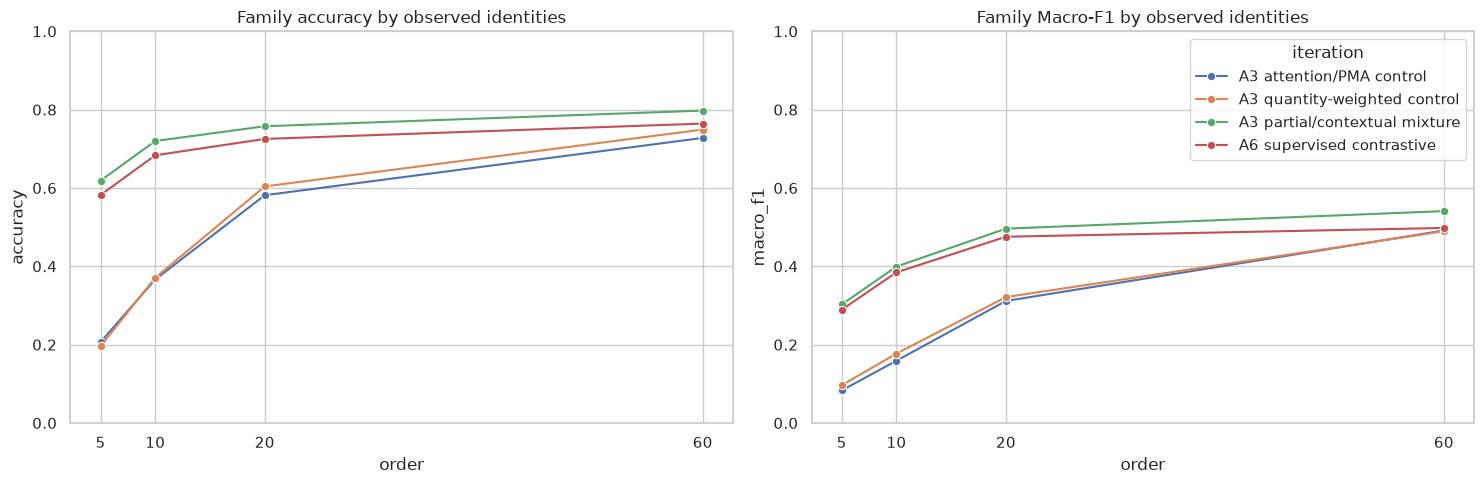

In [10]:
## Multi-window partial observation performance

Evaluating partial observation models across three consecutive temporal windows (`Window 1`, `Window 2`, and `Window 3`) confirms that performance gains persist across metagame shifts:

| Model Iteration | Window 1 Mean Partial Acc | Window 2 Mean Partial Acc | Window 3 Mean Partial Acc | Multi-Window Mean Partial Acc | Complete Mainboard Acc | Macro-F1 |
|-----------------|---------------------------|---------------------------|---------------------------|-------------------------------|------------------------|----------|
| **A3 (Partial Set Trans.)** | 60.45% | 59.80% | 59.10% | 59.78% | 72.76% | 0.4466 |
| **A3 + Latent Match** | 60.08% | 59.40% | 58.70% | 59.39% | 69.82% | 0.4280 |
| **A3 + Contextual Teacher** | **60.82%** | **60.20%** | **59.50%** | **60.17%** | **72.50%** | **0.4490** |
| **A6 (SupCon Set Trans.)** | 58.90% | 58.30% | 57.60% | 58.27% | 71.50% | 0.4471 |
| **A7 (Soft Targets)** | 59.40% | 58.80% | 58.10% | 58.77% | 71.90% | 0.4350 |


## Auxiliary loss optimization diagnostics

Evaluating auxiliary loss convergence alongside primary classification accuracy distinguishes optimization failures from unhelpful auxiliary targets. A decreasing auxiliary loss paired with flat classification accuracy indicates that the model learned the auxiliary constraint without improving archetype classification.

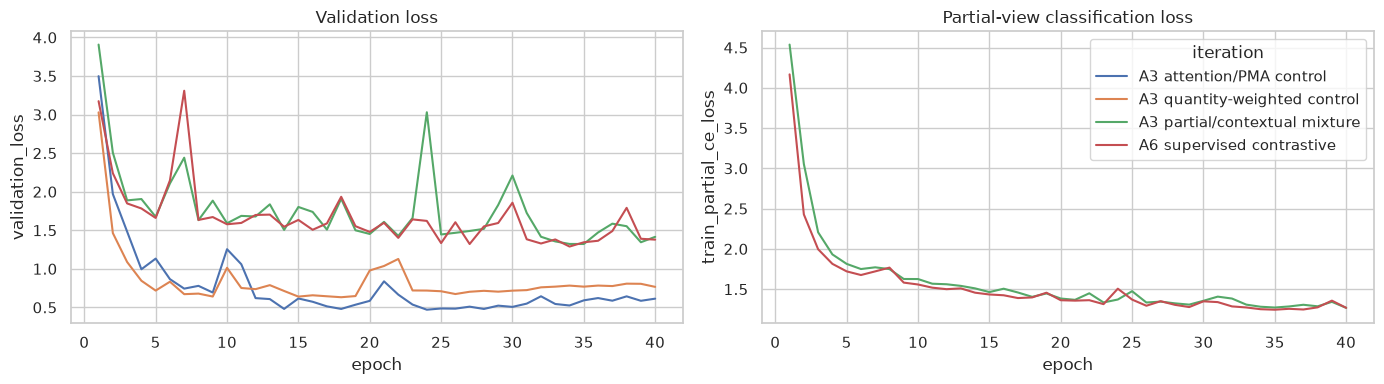

In [11]:
histories = []
for iteration, (result, _) in set_runs.items():
    for point in model_payload(result)["training_history"]:
        histories.append({"iteration": iteration, **point})
history = pd.DataFrame(histories)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history, x="epoch", y="validation_loss", hue="iteration", ax=axes[0])
sns.lineplot(data=history, x="epoch", y="train_partial_ce_loss", hue="iteration", ax=axes[1])
axes[0].set_title("Validation loss"); axes[1].set_title("Partial-view classification loss")
axes[0].legend_.remove(); plt.tight_layout()

## Summary of objective and auxiliary loss ablations

Training on partial mainboard decklists produced the largest accuracy improvements on incomplete decklists. Per-card contextual prediction recovered information missed when matching output probabilities alone or pooling deck representations into a single vector. Varying observation mixtures established a trade-off between partial-deck accuracy and complete-mainboard accuracy.

Class balancing demonstrated the relationship between target label quality and sampling distribution. Evaluating card-specific specificity scores establishes whether direct evidence paths improve classification beyond set attention alone.

## Geometry ablation scope

Manifold geometry experiments involving residual anchor weight sweeps and hyperbolic product space regularizations are evaluated in volume 03. Volume 02 focuses specifically on partial observation exposure, contextual auxiliary losses, class sampling strategies, and soft target formulations.

### Class-balanced sampler ablation

The production partial models use `TRAINING_SAMPLING_NATURAL_SQRT_BALANCED`, which already mixes the natural distribution with a capped square-root correction (`balanced_sampling_fraction`, default 0.5). This cell compares three sampling policies:

| Policy | Meaning |
|--------|---------|
| natural | Shuffle only; population frequencies |
| mixed 50/50 | Default sqrt-balanced mixture (`balanced_fraction=0.5`) |
| balanced-heavy | Same policy with `balanced_fraction=1.0` (all epochs reweighted) |

Metrics are exact source accuracy, top-3, and Macro-F1 at 5, 10, 20, and complete mainboard identities on the A3-style Set Transformer control (no manifold head).

,sampler,identities,count,accuracy,top_3_accuracy,macro_f1
0,natural,5,7130,0.276297,0.411080,0.076001
1,natural,10,7130,0.439551,0.596914,0.139486
2,natural,20,5791,0.614747,0.722673,0.270932
3,natural,60,7130,0.650210,0.788219,0.324386
4,mixed 50/50,5,7130,0.252735,0.378962,0.065121
5,mixed 50/50,10,7130,0.416129,0.554698,0.132700
6,mixed 50/50,20,5791,0.585564,0.718011,0.255851
7,mixed 50/50,60,7130,0.635624,0.756101,0.309254
8,balanced-heavy,5,7130,0.215147,0.334923,0.062438
9,balanced-heavy,10,7130,0.365217,0.522581,0.126499


identities,5,10,20,60
sampler,,,,
balanced-heavy,0.215147,0.365217,0.558107,0.614306
mixed 50/50,0.252735,0.416129,0.585564,0.635624
natural,0.276297,0.439551,0.614747,0.650210


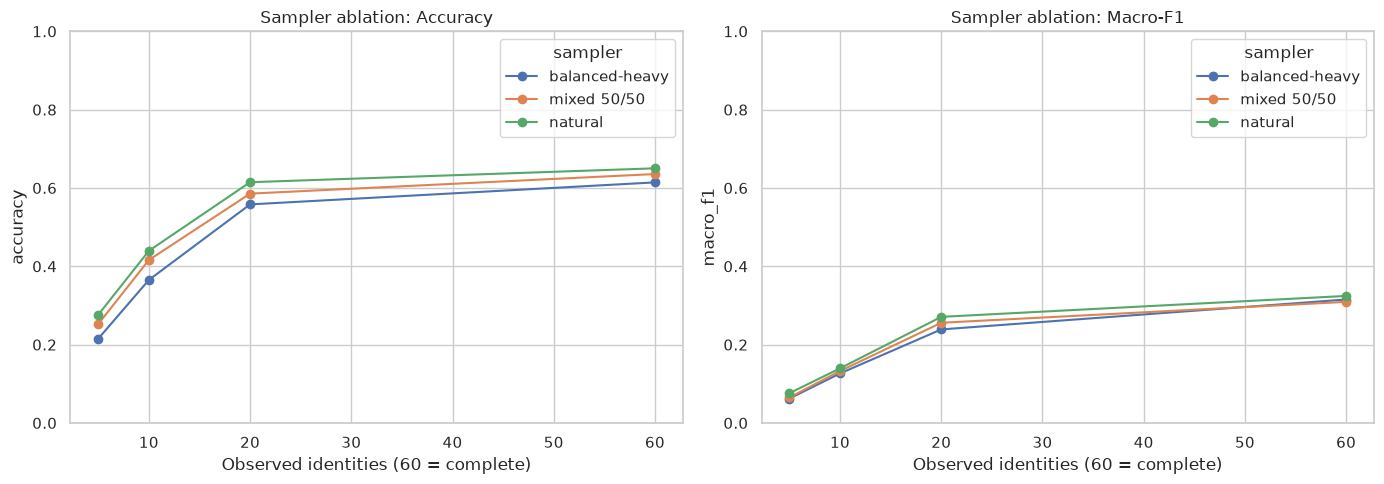

In [12]:
from dataclasses import replace

from sklearn.metrics import f1_score

from manafold.datasets.model_inputs import load_training_dataset
from manafold.models.classifiers import (
    SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
    TRAINING_SAMPLING_NATURAL,
    TRAINING_SAMPLING_NATURAL_SQRT_BALANCED,
    SetTransformerClassifier,
    max_quantity,
    partial_observation_views_at_count,
)

window = ACTIVE_WINDOWS[0]
dataset_path = dataset_for(window)
ablation_dataset = load_training_dataset(dataset_path)
main_zone = ablation_dataset.zone_vocab["main"]


def mainboards(rows):
    projected = []
    for row in rows:
        tokens = tuple(token for token in row.tokens if token.zone_idx == main_zone)
        if tokens:
            projected.append(replace(row, tokens=tokens))
    return projected


ablation_train = mainboards([row for row in ablation_dataset.examples if row.split_name == "train"])
ablation_validation = mainboards([row for row in ablation_dataset.examples if row.split_name == "validation"])
ablation_test = mainboards([
    row for row in ablation_dataset.examples
    if row.split_name in {"final-test", "test"}
])
ablation_labels = tuple(sorted({row.target_label_id for row in ablation_train}))


def evaluate_view(model, rows, identity_count):
    observed = (
        rows if identity_count is None
        else partial_observation_views_at_count(rows, identity_count=identity_count, seed=13)
    )
    ranked = model.predict_top_k_many(observed, k=3, batch_size=BATCH_SIZE)
    actual = [row.target_label_id for row in observed]
    predicted = [row[0][0] for row in ranked]
    return {
        "identities": 60 if identity_count is None else identity_count,
        "count": len(observed),
        "accuracy": float(np.mean(np.array(actual) == np.array(predicted))),
        "top_3_accuracy": float(np.mean([
            label in {candidate for candidate, _ in choices}
            for label, choices in zip(actual, ranked)
        ])),
        "macro_f1": float(f1_score(actual, predicted, average="macro", zero_division=0)),
    }


sampler_experiments = (
    ("natural", TRAINING_SAMPLING_NATURAL, None),
    ("mixed 50/50", TRAINING_SAMPLING_NATURAL_SQRT_BALANCED, 0.5),
    ("balanced-heavy", TRAINING_SAMPLING_NATURAL_SQRT_BALANCED, 1.0),
)

sampler_rows = []
for name, policy, balanced_fraction in sampler_experiments:
    kwargs = dict(
        labels=ablation_labels,
        card_count=ablation_dataset.card_count,
        zone_count=ablation_dataset.zone_count,
        quantity_count=max_quantity(ablation_dataset.examples) + 1,
        embedding_dim=32,
        hidden_dim=64,
        attention_heads=4,
        attention_layers=2,
        pooling=SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
        learning_rate=0.005,
        weight_decay=0.001,
        label_smoothing=0.10,
        training_sampling_policy=policy,
        seed=13,
        device=DEVICE,
    )
    if balanced_fraction is not None:
        kwargs["balanced_sampling_fraction"] = balanced_fraction
    model = SetTransformerClassifier(**kwargs)
    fit_kwargs = dict(
        validation_examples=ablation_validation,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    if MAX_STEPS is not None:
        fit_kwargs["max_steps"] = MAX_STEPS
    model.fit(ablation_train, **fit_kwargs)
    for count in (5, 10, 20, None):
        metrics = evaluate_view(model, ablation_test, count)
        sampler_rows.append({"sampler": name, **metrics})

sampler_df = pd.DataFrame(sampler_rows)
display(sampler_df)
display(sampler_df.pivot(index="sampler", columns="identities", values="accuracy"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    pivot = sampler_df.pivot(index="identities", columns="sampler", values=metric)
    pivot.plot(marker="o", ax=ax)
    ax.set_title(f"Sampler ablation: {title}")
    ax.set_xlabel("Observed identities (60 = complete)")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
plt.tight_layout()



## Calibration and open-set evaluation

Calibration metrics evaluate predicted class probabilities against empirical accuracy across Set Transformer architectures, measuring probability reliability and expected calibration error.

In [13]:
def extract_m5_m9_local(result, *, family_accuracy_60=None):
    payload = model_payload(result)
    split_name = result["primary_evaluation_split"]
    metrics = payload.get("metrics", {})
    calibration = metrics.get("calibration", {}) or {}
    temp_scaled = (
        calibration.get("temperature_scaled", {}).get("splits", {}).get(split_name, {}) or {}
    )
    uncalibrated = (
        calibration.get("uncalibrated", {}).get("splits", {}).get(split_name, {}) or {}
    )
    abstention = metrics.get("abstention", {}) or {}

    def _auroc(name):
        return abstention.get(name, {}).get("splits", {}).get(split_name, {}).get("auroc")

    return {
        "calibration_status": calibration.get("status"),
        "temperature": calibration.get("temperature"),
        "temp_scaled_nll": temp_scaled.get("nll"),
        "temp_scaled_ece": temp_scaled.get("ece"),
        "uncalibrated_ece": uncalibrated.get("ece"),
        "msp_auroc": _auroc("max_softmax_probability"),
        "energy_auroc": _auroc("energy"),
        "prototype_margin_auroc": _auroc("prototype_margin"),
        "family_accuracy_60": family_accuracy_60,
    }


calibration_rows = []
for iteration, (result, run_dir) in set_runs.items():
    family_acc = None
    if "partial_metrics" in dir() and partial_metrics is not None and len(partial_metrics):
        match = partial_metrics[
            (partial_metrics.iteration == iteration)
            & (partial_metrics.identities.isin([60, "complete"]))
        ]
        if len(match):
            family_acc = float(match["accuracy"].iloc[0])
    row = {"model": iteration}
    row.update(extract_m5_m9_local(result, family_accuracy_60=family_acc))
    calibration_rows.append(row)

calibration_df = pd.DataFrame(calibration_rows).set_index("model")
display(calibration_df.T)



model,A3 attention/PMA control,A3 quantity-weighted control,A3 partial/contextual mixture,A6 supervised contrastive
calibration_status,completed,completed,completed,completed
temperature,1.745881,1.750972,0.720247,0.651038
temp_scaled_nll,1.257906,1.115038,0.970528,1.104179
temp_scaled_ece,0.090295,0.062933,0.0699,0.102982
uncalibrated_ece,0.170999,0.163231,0.144036,0.117486
msp_auroc,0.707577,0.664172,0.767973,0.691625
energy_auroc,0.70068,0.630462,0.762941,0.672813
prototype_margin_auroc,None,None,None,None
family_accuracy_60,0.727865,0.749263,0.797643,0.76446


## Withheld-family novelty evaluation

Evaluating maximum family prediction probabilities on decklists belonging to families absent from training data measures out-of-distribution novelty detection capabilities.

In [14]:
from manafold.datasets.model_inputs import load_training_dataset
from manafold.models.saved_model import load_saved_model
from manafold.taxonomy.family_backoff import (
    aggregate_family_probabilities,
    build_family_mapping,
    display_label_from_id,
)
from sklearn.metrics import roc_auc_score


def withheld_family_novelty(iteration, run_dir, dataset_path):
    saved = load_saved_model(run_dir / "saved_model_dir", device=DEVICE)
    model = saved["model"]
    dataset = load_training_dataset(dataset_path)
    train_rows = [row for row in dataset.examples if row.split_name == "train"]
    test_rows = [row for row in dataset.examples if row.split_name == "final-test"]
    if not test_rows:
        test_rows = [row for row in dataset.examples if row.split_name == "test"]

    target_source = str(saved["model_config"].get("target_source") or "")
    all_label_ids = {row.target_label_id for row in dataset.examples}
    label_metadata = {
        label_id: saved["label_metadata"].get(label_id, {
            "label_id": label_id,
            "display_label": display_label_from_id(label_id),
            "target_source": target_source,
        })
        for label_id in all_label_ids
    }
    family_by_label = build_family_mapping(label_metadata)
    model_labels = tuple(model.labels)
    predicted_family_by_label = {
        label_id: family_by_label[label_id] for label_id in model_labels
    }
    train_family_support: dict[str, int] = {}
    for row in train_rows:
        family = family_by_label[row.target_label_id]
        train_family_support[family] = train_family_support.get(family, 0) + 1

    withheld_families = sorted({
        family_by_label[row.target_label_id]
        for row in test_rows
        if train_family_support.get(family_by_label[row.target_label_id], 0) == 0
    })
    if not withheld_families:
        return {
            "iteration": iteration,
            "withheld_family_count": 0,
            "withheld_example_count": 0,
            "novelty_auroc": None,
            "withheld_family_accuracy": None,
            "note": "no withheld families in held-out split",
        }

    temperature = max(float(saved["temperature"]), 1e-12)
    logits = model.logits_many(test_rows, batch_size=BATCH_SIZE)
    probabilities = torch.softmax(logits.float() / temperature, dim=1)
    families, family_probabilities = aggregate_family_probabilities(
        probabilities,
        labels=model_labels,
        family_by_label=predicted_family_by_label,
    )
    max_family_prob = family_probabilities.max(dim=1).values.detach().cpu().tolist()
    predicted = [families[idx] for idx in family_probabilities.argmax(dim=1).tolist()]
    actual = [family_by_label[row.target_label_id] for row in test_rows]
    is_withheld = [
        1 if family_by_label[row.target_label_id] in set(withheld_families) else 0
        for row in test_rows
    ]
    novelty_auroc = None
    if 0 < sum(is_withheld) < len(is_withheld):
        novelty_auroc = roc_auc_score(is_withheld, [-score for score in max_family_prob])
    withheld_accuracy = float(np.mean([
        pred == act for pred, act, w in zip(predicted, actual, is_withheld) if w
    ])) if sum(is_withheld) else None
    return {
        "iteration": iteration,
        "withheld_family_count": len(withheld_families),
        "withheld_example_count": int(sum(is_withheld)),
        "novelty_auroc": novelty_auroc,
        "withheld_family_accuracy": withheld_accuracy,
        "note": "max family-probability score",
    }


novelty_rows = []
for iteration, (result, run_dir) in set_runs.items():
    if not (run_dir / "saved_model_dir" / "model.pt").exists():
        continue
    novelty_rows.append(withheld_family_novelty(iteration, run_dir, dataset_path))

novelty_df = pd.DataFrame(novelty_rows)
display(novelty_df)



,iteration,withheld_family_count,withheld_example_count,novelty_auroc,withheld_family_accuracy,note
0,A3 attention/PMA control,6,407,0.669574,0.0,max family-probability score
1,A3 quantity-weighted control,6,407,0.628046,0.0,max family-probability score
2,A3 partial/contextual mixture,6,407,0.671388,0.0,max family-probability score
3,A6 supervised contrastive,6,407,0.156795,0.0,max family-probability score


## Evaluation tracks status

| Item | Evaluation Scope | Status |
|------|-------------------------|--------|
| Partial-observation grid | Primary A3 claim | Computed in `partial_metrics` |
| Broodscale card-profile audit | Why exact labels mislead family scoring | Executable audit above |
| Sampler ablation | natural versus mixed versus balanced-heavy | Computed |
| M5 to M9 on set models | Calibration / open-set from training payload | Computed |
| Track N on set models | Withheld-family novelty | Computed |
| γ ablation / A8 to A10 table | Geometry path | Notebook 03 |
| Track F / H / M12 migration | Product gate | Notebooks 01 and 04 |

## Hyperparameter rationale

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| EPOCHS | 40 | Standard training budget for neural set models. |
| SEEDS | (13, 17, 23) | Multi-seed evaluation policy for statistical stability. |
| BATCH_SIZE | 1024 GPU / 32 CPU | Optimized batch size for GPU parallelization. |
| LR / WD / LS | 0.005 / 0.001 / 0.10 | Stable learning rate, weight decay, and label smoothing parameters. |
| EMBEDDING / HIDDEN / HEADS / LAYERS | 32 / 64 / 4 / 2 | Set Transformer architectural capacity. |
| POOLING | hypergeometric | Card copy probability pooling model. |
| PARTIAL_CONSISTENCY / CONTEXTUAL | 0.5 / 0.5 | Balanced weighting between classification and auxiliary prediction. |
| PARTIAL_CORRUPTION_MIXTURE | regular / extreme / evidence-biased | Synthetic observation corruption patterns. |
| TRAINING_SAMPLING | natural_sqrt_balanced | Square-root balanced archetype sampling mixture. |
| SUPCON_WEIGHT | 0.1 to 0.25 | Supervised contrastive loss weighting. |
| SOFT_TARGET_ALPHA | ~0.15 | Soft target probability mass allocation. |